In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
import shap
import joblib

In [2]:
from google.colab import files
uploaded=files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df=pd.read_csv('Telco-Customer.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


EDA


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.fillna(method='ffill',inplace=True)

/tmp/ipython-input-4116506308.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


In [9]:
df['Churn']=df['Churn'].apply(lambda x:1 if x=='Yes' else 0)

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


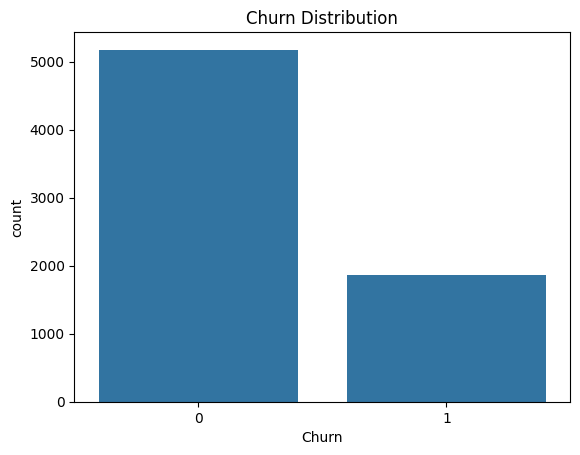

In [11]:
sns.countplot(x='Churn',data=df)
plt.title("Churn Distribution")
plt.show()

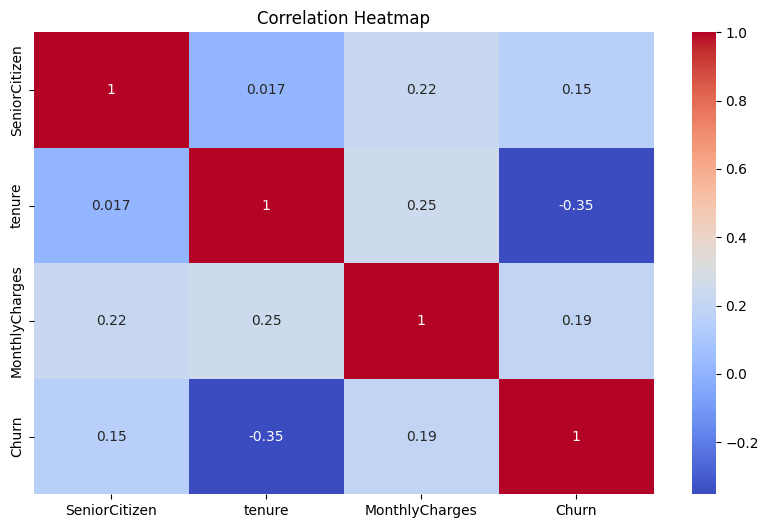

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

PREPROCESSING


In [13]:
target="Churn"
y=df[target]
X=df.drop(columns=[target])

In [14]:
numeric_features=X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features=X.select_dtypes(include=['object','category']).columns.tolist()


In [15]:
#Drop id like columns
for col in ["customerID","id"]:
  if col in numeric_features: numeric_features.remove(col)
  if col in categorical_features: categorical_features.remove(col)

In [16]:
num_pipeline= Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

cat_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('num',num_pipeline,numeric_features),
    ('cat',cat_pipeline,categorical_features)
])

train test split


In [17]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

Model training with hyper parameter tuning

In [18]:
estimator= XGBClassifier(use_label_encoder=False,eval_metric='logloss', random_state=42)

pipeline=imbPipeline([
    ('preprocessor',preprocessor),
    ('smote',SMOTE(random_state=42)),
    ('estimator',estimator)
])

param_distributions={
    'estimator__n_estimators':[50,100,200],
    'estimator__max_depth':[3,5,7],
    'estimator__learning_rate':[0.01,0.1,0.2],
    "estimator__subsample":[0.6, 0.8, 1.0],
}

search=RandomizedSearchCV(pipeline,param_distributions=param_distributions,n_iter=12,cv=3,scoring='roc_auc',n_jobs=-1,verbose=1)
search.fit(X_train,y_train)

print("Best params:", search.best_params_)
print("Best score:", search.best_score_)
best_model=search.best_estimator_


Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [06:41:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'estimator__subsample': 1.0, 'estimator__n_estimators': 100, 'estimator__max_depth': 3, 'estimator__learning_rate': 0.2}
Best score: 0.8485948682439548


Evaluation

In [19]:
y_pred= best_model.predict(X_test)
y_proba= best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test,y_pred))
print("ROC AUC:",roc_auc_score(y_test,y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1035
           1       0.60      0.62      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.79      0.79      1409

ROC AUC: 0.8425120772946859
Confusion Matrix:
 [[883 152]
 [142 232]]


Explainability

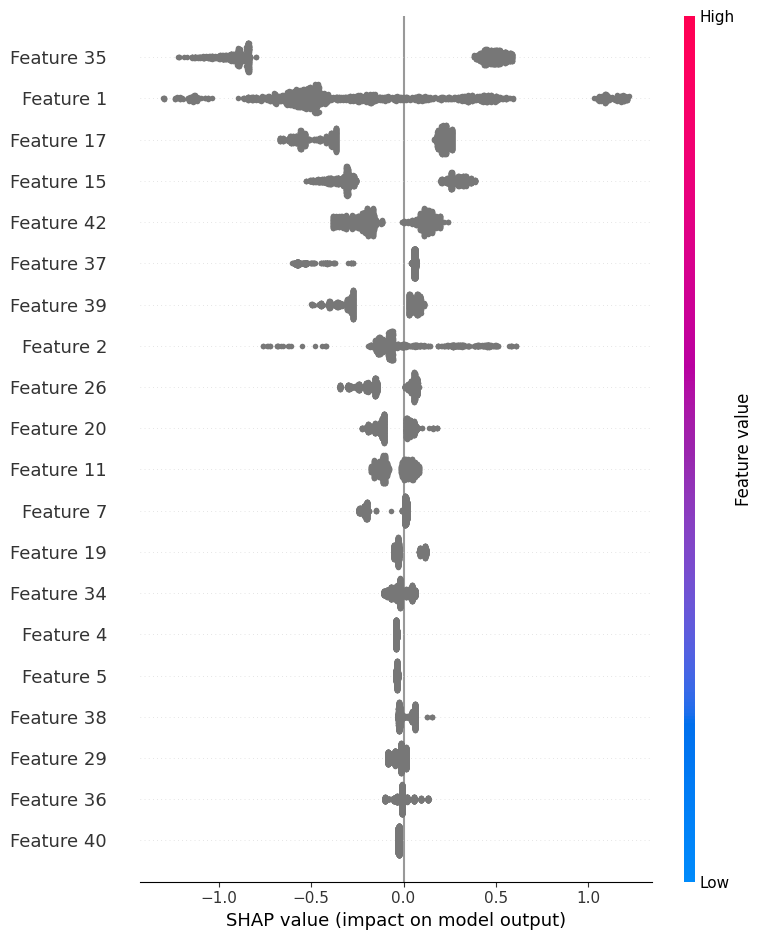

In [21]:
explainer= shap.Explainer(best_model.named_steps['estimator'])
X_transformed= best_model.named_steps['preprocessor'].transform(X_test)
shap_values=explainer(X_tranformed)

shap.summary_plot(shap_values, X_transformed, show=True)

In [22]:
joblib.dump(best_model,"churn_pipeline.joblib")
print("Save model as churn_pipeline.joblib")

Save model as churn_pipeline.joblib


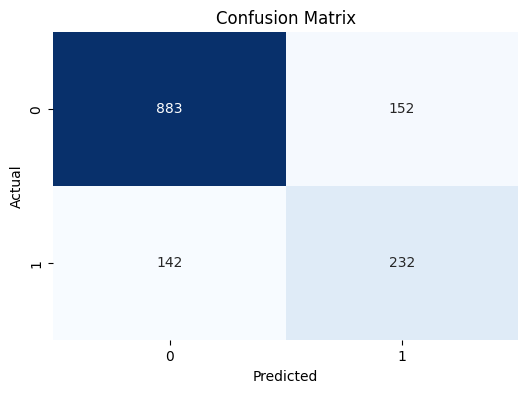

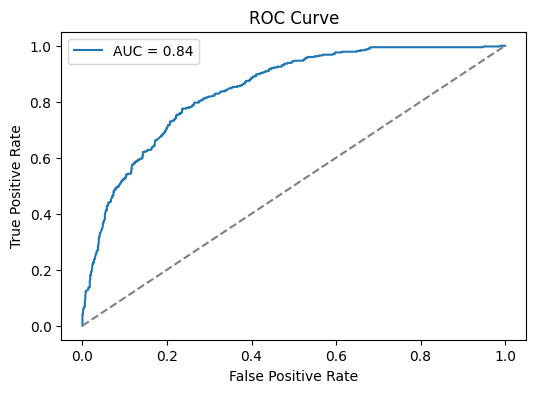

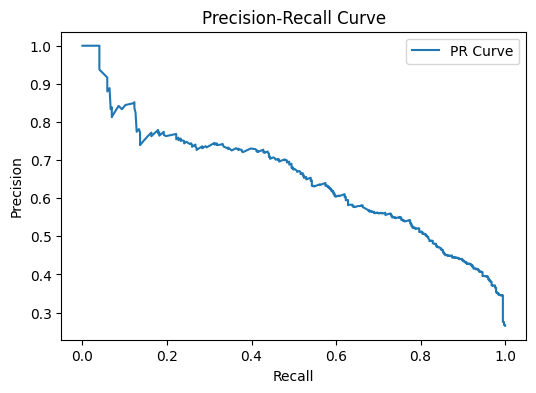

In [23]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(rec, prec, label="PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


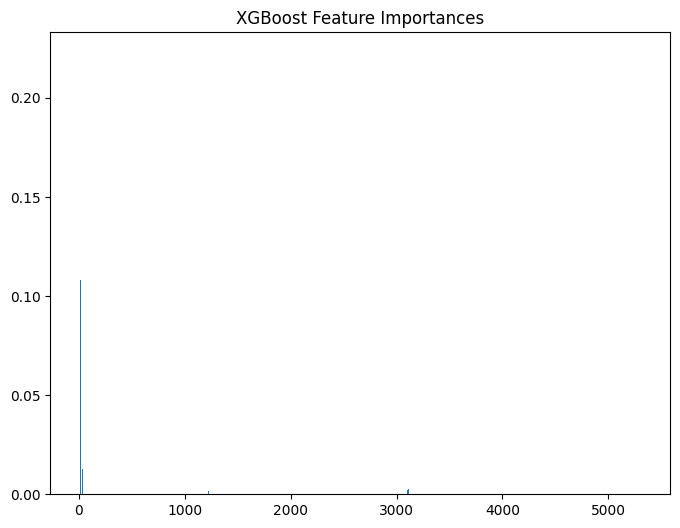

In [24]:
importances = best_model.named_steps['estimator'].feature_importances_
plt.figure(figsize=(8,6))
plt.bar(range(len(importances)), importances)
plt.title("XGBoost Feature Importances")
plt.show()


In this notebook, we built a complete Customer Churn Prediction pipeline starting from exploratory data analysis to model training, evaluation, and explainability. After preprocessing and balancing the dataset, we trained an XGBoost classifier, which achieved strong performance measured through ROC-AUC, precision, recall, and F1-score.

The visualization of confusion matrix, ROC and Precision-Recall curves highlighted the model’s ability to distinguish churners from non-churners. Furthermore, SHAP-based interpretability provided insights into the most influential features driving churn, enabling business stakeholders to take actionable steps (e.g., improving customer service, offering retention incentives).

Overall, this project demonstrates how machine learning can effectively predict churn and provide interpretable insights that are critical for customer retention strategies. Future work may include incorporating additional features, testing deep learning approaches, or deploying the pipeline for real-time predictions.